# Running Cy2path on positive control datasets

***

Jan T. Schleicher, 2025

Here, we run Cy2path on simulated data with known ground truth trajectories as a positive control.
We create strongly simplified processes in two dimensions and project cells into a higher dimensional space.
This allows us to have well-defined ground truths with RNA velocities pointing in the right direction.

In [1]:
import os

import cy2path as c2p
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
from matplotlib import pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

In [2]:
OUT_DIR = "../data/simulations/"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
def generate_adata(means, directions, edges, points_per_cluster, target_dim=100):
    rng = np.random.default_rng(42)
    labels = []
    data = []
    velocities = []

    ax = plt.gca()

    # Generate main clusters
    for i, (mean, direction) in enumerate(zip(means, directions)):
        points = rng.multivariate_normal(
            mean=mean, cov=np.eye(2), size=points_per_cluster
        )
        data.append(points)
        ax.scatter(*points.T, label=i)
        labels.extend([f"{i}"] * points_per_cluster)
        velocities.append(
            rng.multivariate_normal(
                mean=direction, cov=0.01 * np.eye(2), size=points_per_cluster
            ),
        )

    # Interpolate data points between main clusters
    for idx_1, idx_2 in edges:
        points = rng.multivariate_normal(
            mean=means[idx_1], cov=np.eye(2), size=points_per_cluster
        )
        points += (np.array(means[idx_2]) - np.array(means[idx_1])) * rng.random(
            points_per_cluster
        )[:, None]
        data.append(points)
        ax.scatter(*points.T)
        labels.extend([f"{idx_1}>{idx_2}"] * points_per_cluster)

        if means[idx_2][1] > means[idx_1][1]:
            dir_y = 1
        elif means[idx_2][1] == means[idx_1][1]:
            dir_y = 0
        else:
            dir_y = -1

        if means[idx_2][0] > means[idx_1][0]:
            dir_x = 1
        elif means[idx_2][0] == means[idx_1][0]:
            dir_x = 0
        else:
            dir_x = -1
        direction = np.asarray([dir_x, dir_y])
        velocities.append(
            rng.multivariate_normal(
                mean=direction, cov=0.01 * np.eye(2), size=points_per_cluster
            ),
        )
    ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
    data = np.concatenate(data)
    velocities = np.concatenate(velocities)
    quiver_kwargs = {
        "angles": "xy",
        "scale_units": "xy",
        "edgecolors": "k",
        "scale": 1,
        "width": 0.001,
        "linewidth": 0.2,
        "zorder": 3,
    }
    ax.quiver(*data.T, *velocities.T, color="k", alpha=0.5, **quiver_kwargs)

    # Project into higher dimension
    projection_matrix = rng.standard_normal(size=(2, target_dim))
    points_highd = data @ projection_matrix
    points_highd += 10 * rng.multivariate_normal(
        mean=np.zeros(target_dim), cov=np.eye(target_dim), size=len(data)
    )
    velocities_highd = velocities @ projection_matrix

    # Create AnnData object
    adata = sc.AnnData(
        X=points_highd,
        obs=pd.DataFrame({"cluster": labels}),
        obsm={"X_orig": data, "X_velocity_orig": velocities},
        layers={"spliced": points_highd, "velocity": velocities_highd},
    )
    return adata

In [4]:
num_chains = 1000

## Single bifurcation

First, we simulate a dataset with a single root region and two end points, resulting in a shared trunk and two branches.

AnnData object with n_obs × n_vars = 1300 × 100
    obs: 'cluster'
    obsm: 'X_orig', 'X_velocity_orig'
    layers: 'spliced', 'velocity'

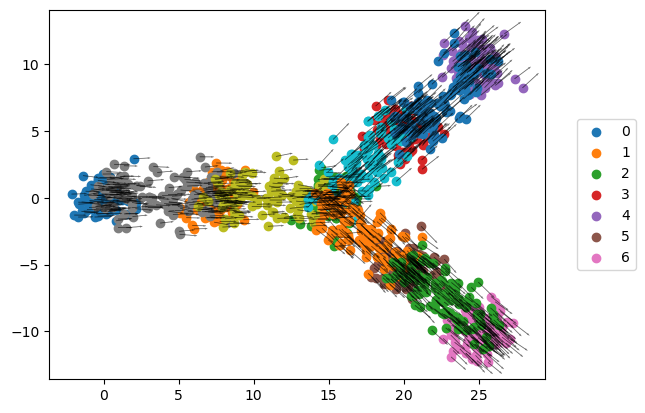

In [5]:
# Create data for a simple bifurcation
points_per_cluster = 100
root = np.array([0, 0])
branch_point = np.array([15, 0])
end_top = np.array([25, 10])
end_bottom = np.array([25, -10])
means = [
    root,
    0.5 * (branch_point + root),
    branch_point,
    0.5 * (end_top + branch_point),
    end_top,
    0.5 * (end_bottom + branch_point),
    end_bottom,
]
directions = [[1, 0], [1, 0], [1, 0], [1, 1], [1, 1], [1, -1], [1, -1]]
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (2, 5), (5, 6)]

adata = generate_adata(means, directions, edges, points_per_cluster)
adata

computing velocity graph (using 1/10 cores)


  0%|          | 0/1300 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cluster'}>

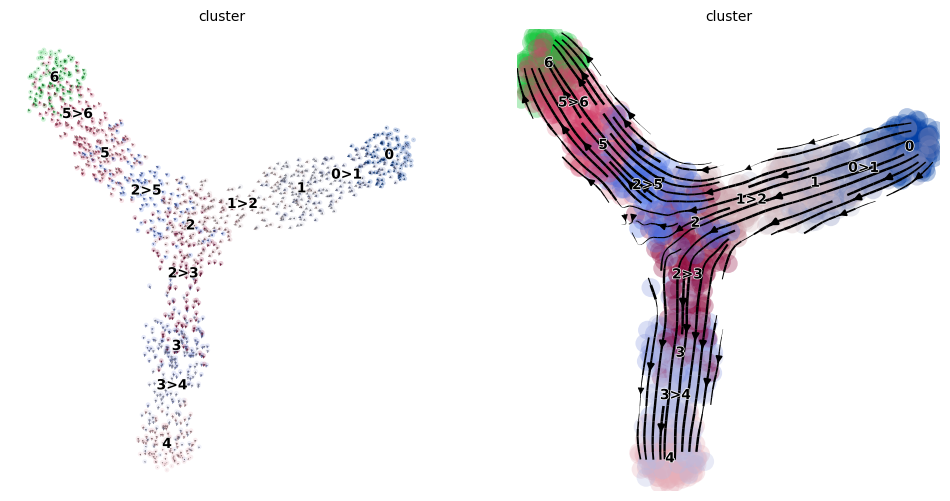

In [6]:
# Compute neighbors, UMAP, velocity embedding
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata, mode_neighbors="connectivities")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
scv.pl.velocity_embedding(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[0], show=False
)
scv.pl.velocity_embedding_stream(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[1], show=False
)

computing terminal states
    identified 1 region of root cells and 2 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


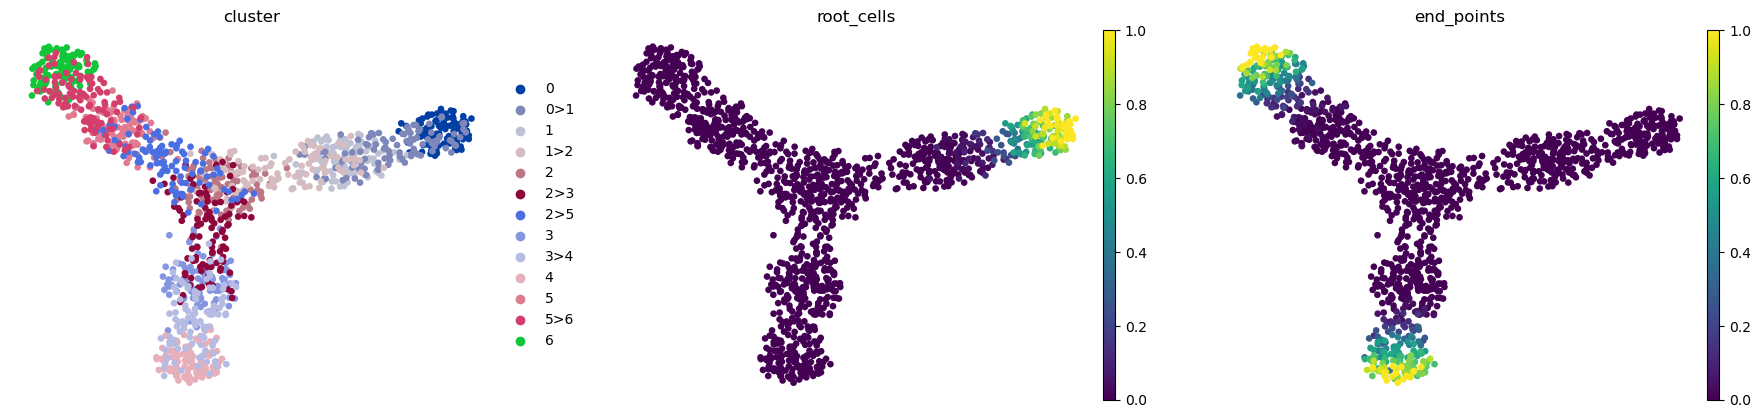

In [7]:
# Compute terminal states and transition matrix
scv.tl.terminal_states(adata)
adata.obsp["T_forward"] = scv.utils.get_transition_matrix(adata, self_transitions=False)
sc.pl.umap(adata, color=["cluster", "root_cells", "end_points"], frameon=False)

In [8]:
# Run Cy2path analyis
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    num_chains=num_chains,
    num_lineages="auto",
    max_lineages=6,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 26 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Finding optimal number of lineages between 2 and 6:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:root:Optimal number of lineages is 2 with silhouette score 0.505


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

<Axes: >

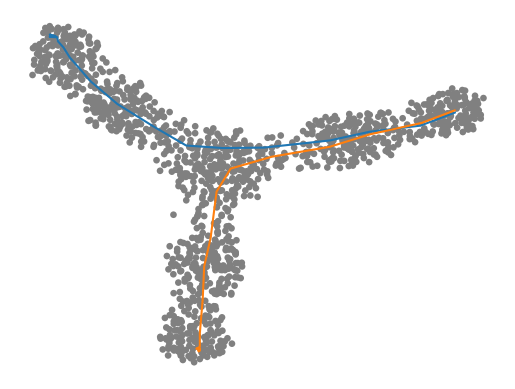

In [9]:
c2p.plot_cytopath_lineages(adata)

In [10]:
adata.uns["cytopath"]["silhouette_scores"] = {
    str(key): val for key, val in adata.uns["cytopath"]["silhouette_scores"].items()
}
adata.write_h5ad(os.path.join(OUT_DIR, "adata_bifurcation.h5ad"))

## Two bifurcations

Next, we generate toy data with two bifurcations, resulting in three ground-truth lineages.

AnnData object with n_obs × n_vars = 2500 × 100
    obs: 'cluster'
    obsm: 'X_orig', 'X_velocity_orig'
    layers: 'spliced', 'velocity'

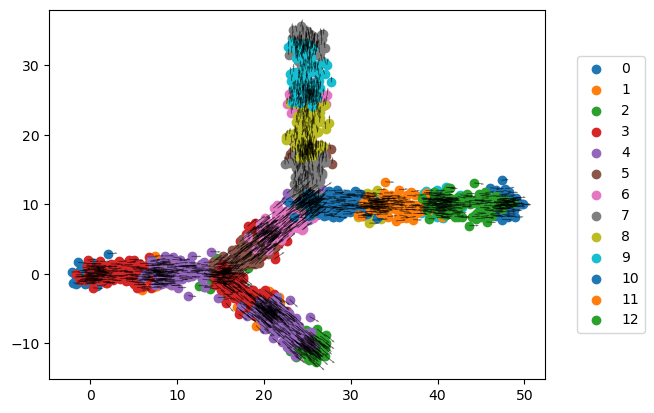

In [11]:
points_per_cluster = 100
root = np.array([0, 0])
branch_points = [np.array([15, 0]), np.array([25, 10])]
ends = [np.array([25, 32.5]), np.array([47.5, 10]), np.array([25, -10])]
means = [
    root,
    0.5 * (branch_points[0] + root),
    branch_points[0],
    0.5 * (branch_points[0] + branch_points[1]),
    branch_points[1],
    branch_points[1] + 1 / 3 * (ends[0] - branch_points[1]),
    branch_points[1] + 2 / 3 * (ends[0] - branch_points[1]),
    ends[0],
    branch_points[1] + 1 / 3 * (ends[1] - branch_points[1]),
    branch_points[1] + 2 / 3 * (ends[1] - branch_points[1]),
    ends[1],
    0.5 * (branch_points[0] + ends[2]),
    ends[2],
]
directions = [
    [1, 0],
    [1, 0],
    [1, 0],
    [1, 1],
    [1, 1],
    [0, 1],
    [0, 1],
    [0, 1],
    [1, 0],
    [1, 0],
    [1, 0],
    [1, -1],
    [1, -1],
]
edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (4, 8),
    (8, 9),
    (9, 10),
    (2, 11),
    (11, 12),
]

adata = generate_adata(means, directions, edges, points_per_cluster)
adata

computing velocity graph (using 1/10 cores)


  0%|          | 0/2500 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cluster'}>

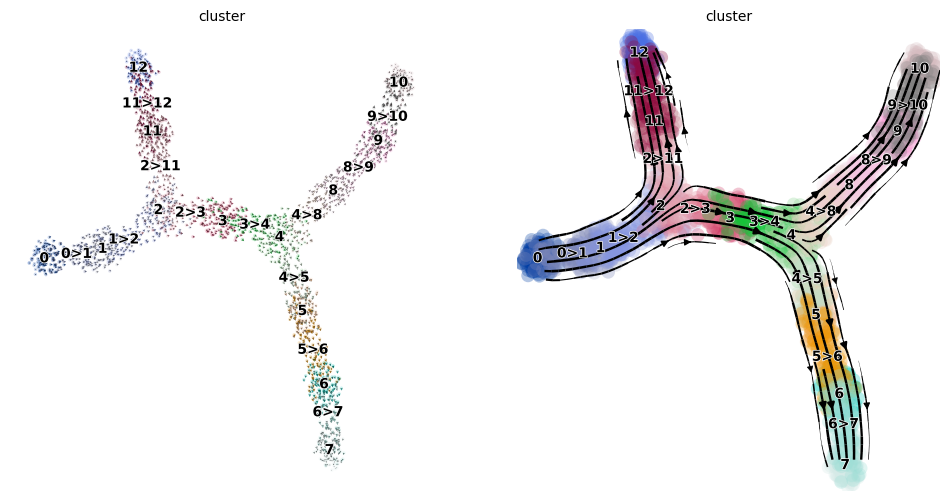

In [12]:
# Compute neighbors, UMAP, velocity embedding
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata, mode_neighbors="connectivities")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
scv.pl.velocity_embedding(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[0], show=False
)
scv.pl.velocity_embedding_stream(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[1], show=False
)

computing terminal states
    identified 1 region of root cells and 3 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


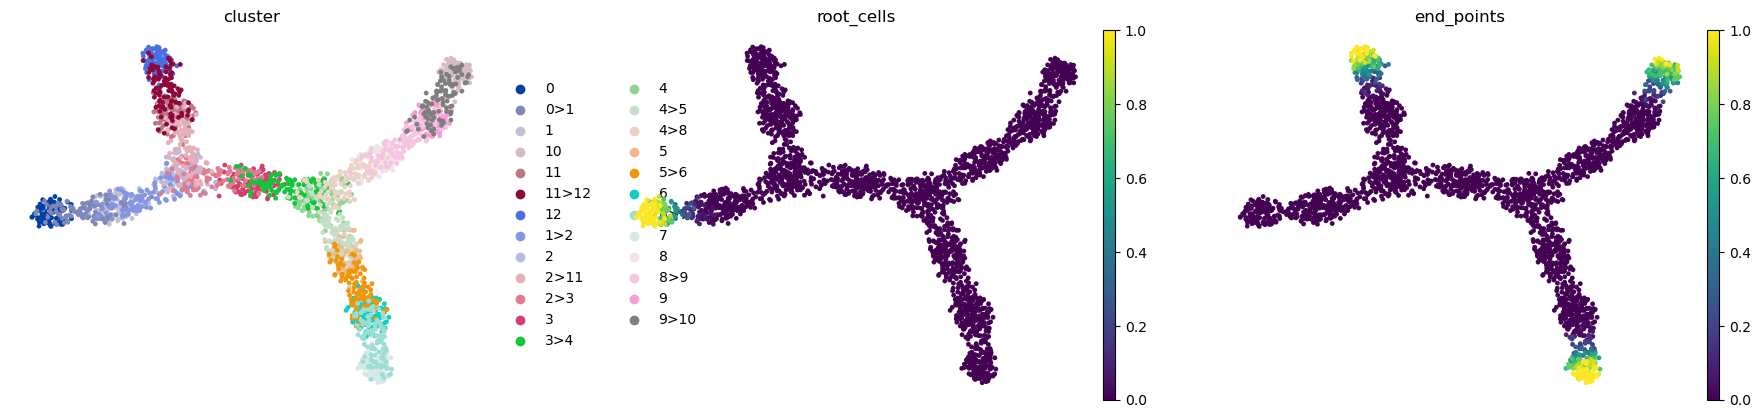

In [13]:
# Compute terminal states and transition matrix
scv.tl.terminal_states(adata)
adata.obsp["T_forward"] = scv.utils.get_transition_matrix(adata, self_transitions=False)
sc.pl.umap(adata, color=["cluster", "root_cells", "end_points"], frameon=False)

In [14]:
# Run Cy2path analyis
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    num_chains=num_chains,
    num_lineages="auto",
    max_lineages=6,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 35 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Finding optimal number of lineages between 2 and 6:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:root:Optimal number of lineages is 3 with silhouette score 0.595


Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

<Axes: >

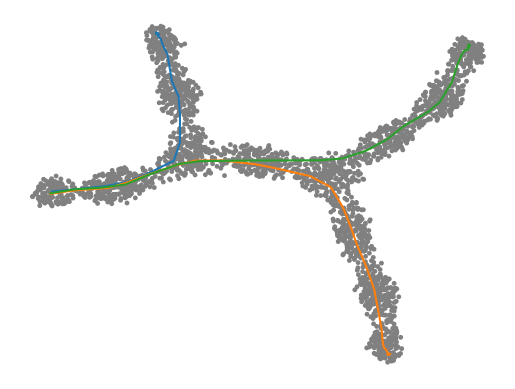

In [15]:
c2p.plot_cytopath_lineages(adata)

In [16]:
adata.uns["cytopath"]["silhouette_scores"] = {
    str(key): val for key, val in adata.uns["cytopath"]["silhouette_scores"].items()
}
adata.write_h5ad(os.path.join(OUT_DIR, "adata_two_bifurcations.h5ad"))

## Three bifurcations

Next, we generate toy data with three bifurcations, resulting in four ground-truth lineages.

AnnData object with n_obs × n_vars = 3700 × 100
    obs: 'cluster'
    obsm: 'X_orig', 'X_velocity_orig'
    layers: 'spliced', 'velocity'

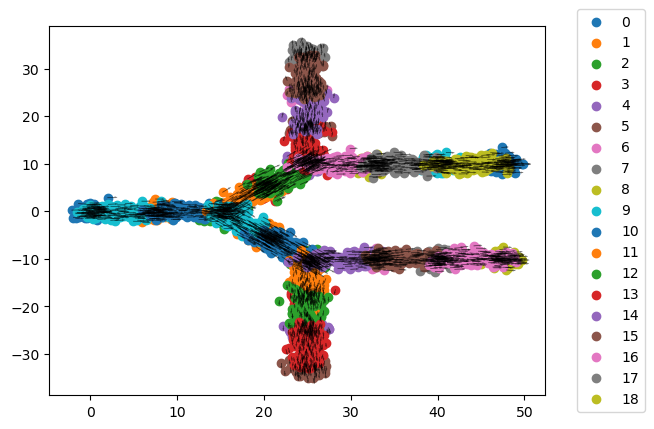

In [17]:
points_per_cluster = 100
root = np.array([0, 0])
branch_points = [np.array([15, 0]), np.array([25, 10]), np.array([25, -10])]
ends = [
    np.array([25, 32.5]),
    np.array([47.5, 10]),
    np.array([25, -32.5]),
    np.array([47.5, -10]),
]
means = [
    root,
    0.5 * (branch_points[0] + root),
    branch_points[0],
    0.5 * (branch_points[0] + branch_points[1]),
    branch_points[1],
    branch_points[1] + 1 / 3 * (ends[0] - branch_points[1]),
    branch_points[1] + 2 / 3 * (ends[0] - branch_points[1]),
    ends[0],
    branch_points[1] + 1 / 3 * (ends[1] - branch_points[1]),
    branch_points[1] + 2 / 3 * (ends[1] - branch_points[1]),
    ends[1],
    0.5 * (branch_points[0] + branch_points[2]),
    branch_points[2],
    branch_points[2] + 1 / 3 * (ends[2] - branch_points[2]),
    branch_points[2] + 2 / 3 * (ends[2] - branch_points[2]),
    ends[2],
    branch_points[2] + 1 / 3 * (ends[3] - branch_points[2]),
    branch_points[2] + 2 / 3 * (ends[3] - branch_points[2]),
    ends[3],
]
directions = [
    [1, 0],
    [1, 0],
    [1, 0],
    [1, 1],
    [1, 1],
    [0, 1],
    [0, 1],
    [0, 1],
    [1, 0],
    [1, 0],
    [1, 0],
    [1, -1],
    [1, -1],
    [0, -1],
    [0, -1],
    [0, -1],
    [1, 0],
    [1, 0],
    [1, 0],
]
edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (4, 8),
    (8, 9),
    (9, 10),
    (2, 11),
    (11, 12),
    (12, 13),
    (13, 14),
    (14, 15),
    (12, 16),
    (16, 17),
    (17, 18),
]

adata = generate_adata(means, directions, edges, points_per_cluster)
adata

computing velocity graph (using 1/10 cores)


  0%|          | 0/3700 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cluster'}>

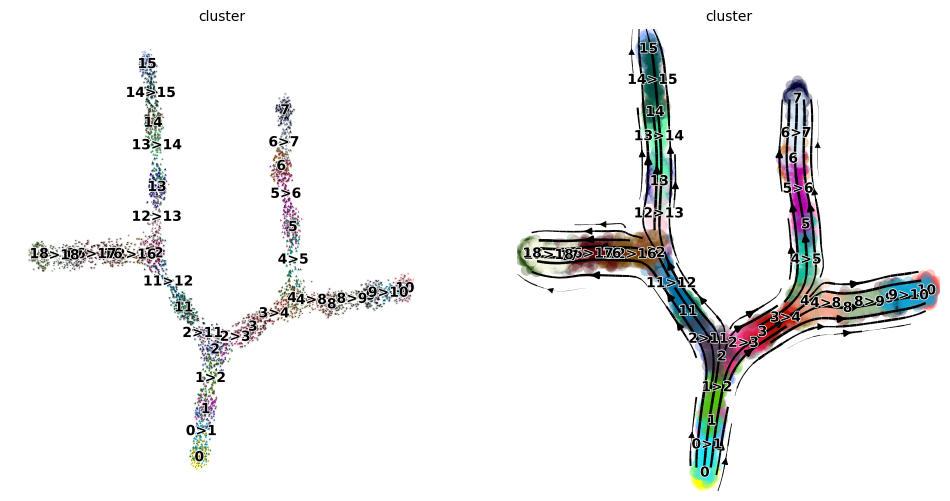

In [18]:
# Compute neighbors, UMAP, velocity embedding
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata, mode_neighbors="connectivities")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
scv.pl.velocity_embedding(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[0], show=False
)
scv.pl.velocity_embedding_stream(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[1], show=False
)

computing terminal states
    identified 1 region of root cells and 4 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


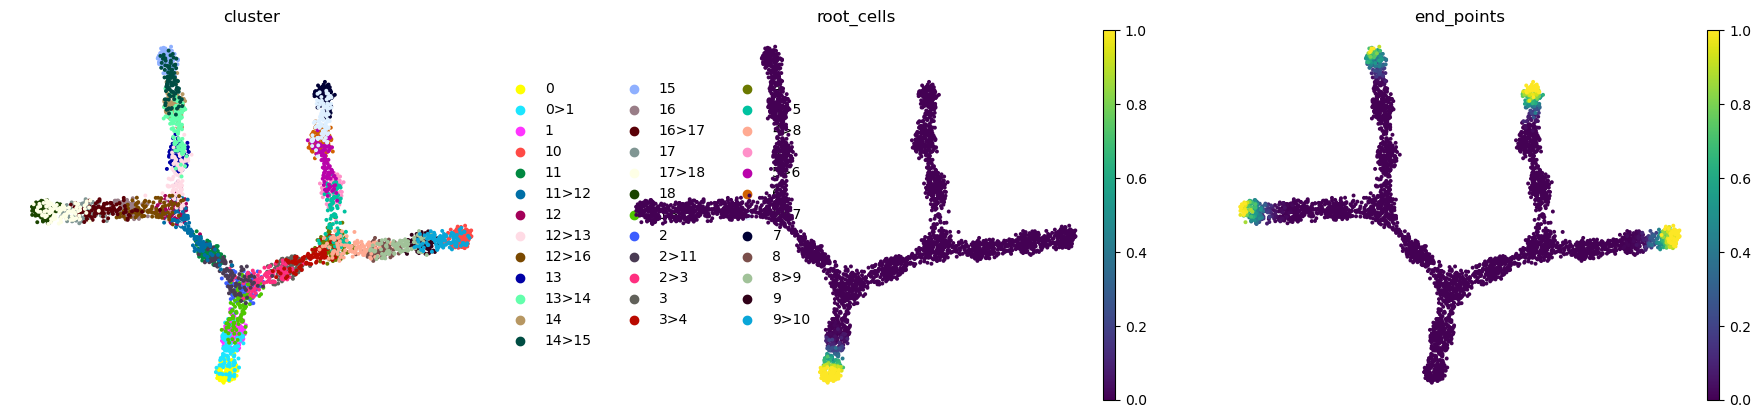

In [19]:
# Compute terminal states and transition matrix
scv.tl.terminal_states(adata)
adata.obsp["T_forward"] = scv.utils.get_transition_matrix(adata, self_transitions=False)
sc.pl.umap(adata, color=["cluster", "root_cells", "end_points"], frameon=False)

In [20]:
# Run Cy2path analyis
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    num_chains=num_chains,
    num_lineages="auto",
    max_lineages=6,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 39 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Finding optimal number of lineages between 2 and 6:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:root:Optimal number of lineages is 4 with silhouette score 0.587


Computing coordinates:   0%|          | 0/4 [00:00<?, ? lineage/s]

<Axes: >

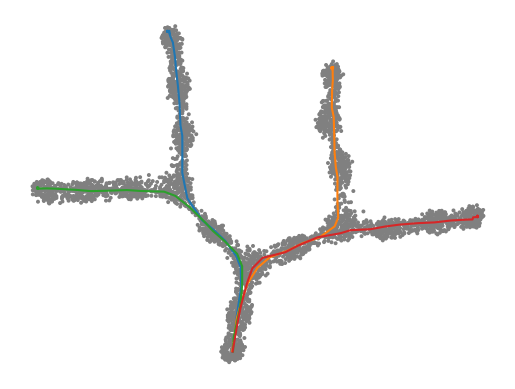

In [21]:
c2p.plot_cytopath_lineages(adata)

In [22]:
adata.uns["cytopath"]["silhouette_scores"]

{2: 0.49283152753694665,
 3: 0.5512046370977034,
 4: 0.5872292376052879,
 5: 0.4507231083899043,
 6: 0.27284826160827746}

In [23]:
adata.uns["cytopath"]["silhouette_scores"] = {
    str(key): val for key, val in adata.uns["cytopath"]["silhouette_scores"].items()
}
adata.write_h5ad(os.path.join(OUT_DIR, "adata_three_bifurcations.h5ad"))

## Convergent trajectories
Next, we generate toy data with a bifurcation and convergence, resulting in two ground-truth lineages.

AnnData object with n_obs × n_vars = 2000 × 100
    obs: 'cluster'
    obsm: 'X_orig', 'X_velocity_orig'
    layers: 'spliced', 'velocity'

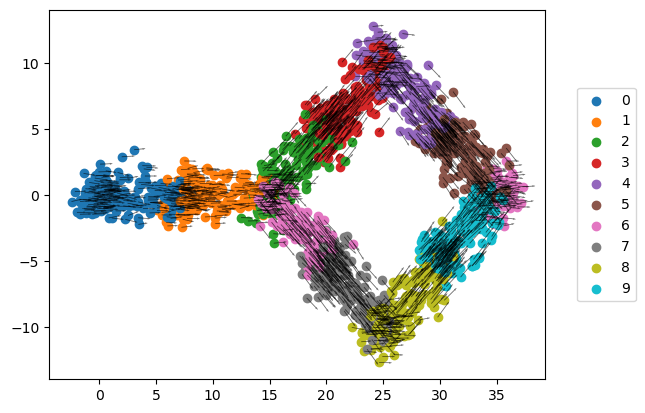

In [24]:
points_per_cluster = 100
root = np.array([0, 0])
branch_point = np.array([15, 0])
top = np.array([25, 10])
bottom = np.array([25, -10])
end = np.array([35, 0])
means = [
    root,
    0.5 * (branch_point + root),
    branch_point,
    0.5 * (branch_point + top),
    top,
    0.5 * (top + end),
    end,
    0.5 * (branch_point + bottom),
    bottom,
    0.5 * (bottom + end),
]
directions = [
    [1, 0],
    [1, 0],
    [1, 0],
    [1, 1],
    [1, 0],
    [1, -1],
    [1, 0],
    [1, -1],
    [1, 0],
    [1, 1],
]
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (2, 7), (7, 8), (8, 9), (9, 6)]

adata = generate_adata(means, directions, edges, points_per_cluster)
adata

computing velocity graph (using 1/10 cores)


  0%|          | 0/2000 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cluster'}>

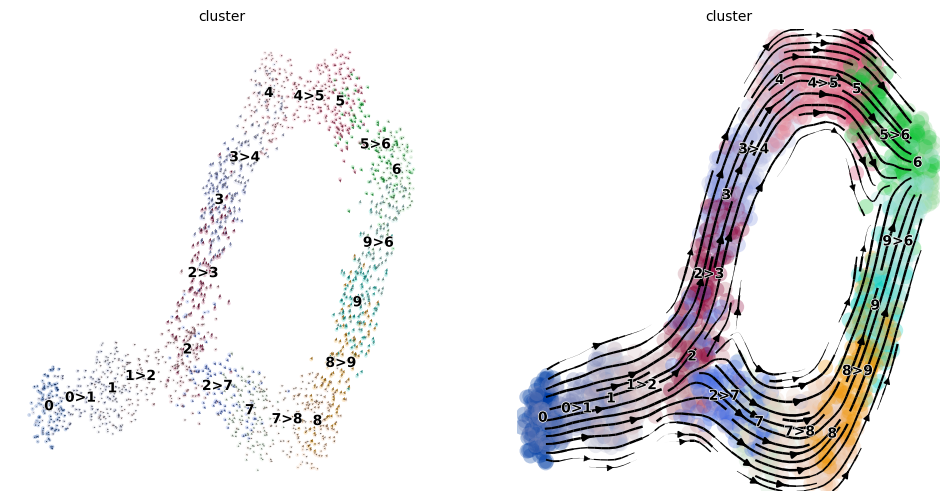

In [25]:
# Compute neighbors, UMAP, velocity embedding
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata, mode_neighbors="connectivities")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
scv.pl.velocity_embedding(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[0], show=False
)
scv.pl.velocity_embedding_stream(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[1], show=False
)

computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


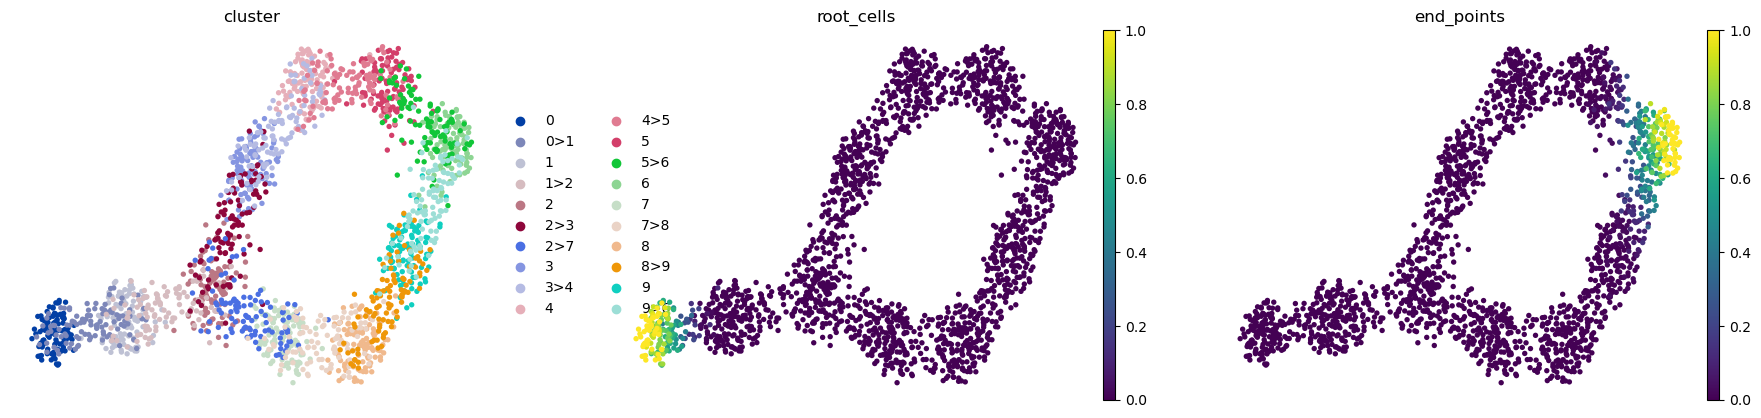

In [26]:
# Compute terminal states and transition matrix
scv.tl.terminal_states(adata)
adata.obsp["T_forward"] = scv.utils.get_transition_matrix(adata, self_transitions=False)
sc.pl.umap(adata, color=["cluster", "root_cells", "end_points"], frameon=False)

In [27]:
# Run Cy2path analyis
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    num_chains=1000,
    num_lineages="auto",
    max_lineages=6,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 27 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Finding optimal number of lineages between 2 and 6:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:root:Optimal number of lineages is 2 with silhouette score 0.156


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

<Axes: >

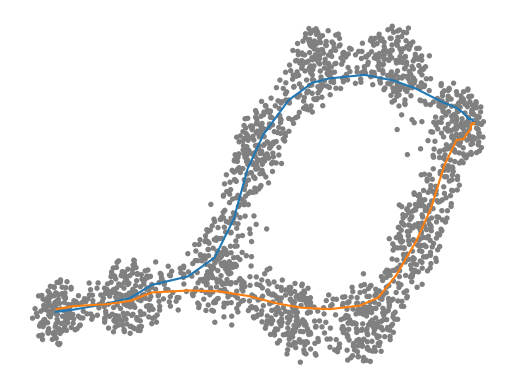

In [28]:
c2p.plot_cytopath_lineages(adata)

In [29]:
adata.uns["cytopath"]["silhouette_scores"] = {
    str(key): val for key, val in adata.uns["cytopath"]["silhouette_scores"].items()
}
adata.write_h5ad(os.path.join(OUT_DIR, "adata_convergent.h5ad"))

## Trajectories with a cycle

Next, we generate toy data with a cycle and a bifurcation, resulting in two ground-truth lineages.

AnnData object with n_obs × n_vars = 2400 × 100
    obs: 'cluster'
    obsm: 'X_orig', 'X_velocity_orig'
    layers: 'spliced', 'velocity'

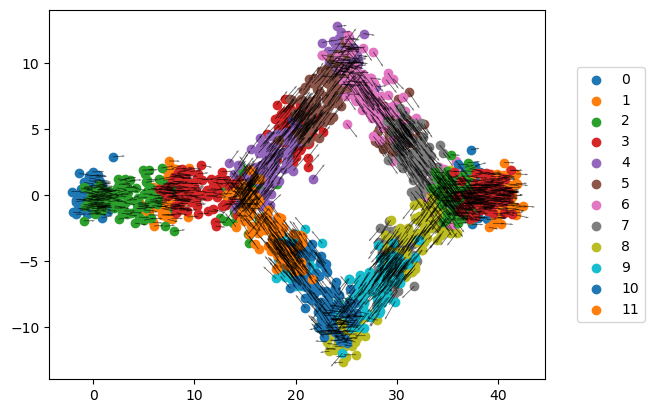

In [30]:
points_per_cluster = 100
root = np.array([0, 0])
branch_points = [np.array([15, 0]), np.array([35, 0])]
top = np.array([25, 10])
bottom = np.array([25, -10])
end = np.array([40, 0])
means = [
    root,
    0.5 * (root + branch_points[0]),
    branch_points[0],
    0.5 * (branch_points[0] + top),
    top,
    0.5 * (top + branch_points[1]),
    branch_points[1],
    0.5 * (branch_points[1] + bottom),
    bottom,
    0.5 * (bottom + branch_points[0]),
    0.5 * (branch_points[1] + end),
    end,
]
directions = [
    [1, 0],
    [1, 0],
    [1, 1],
    [1, 1],
    [1, 0],
    [1, -1],
    [1, -1],
    [-1, -1],
    [-1, 0],
    [-1, 1],
    [1, 0],
    [1, 0],
]
edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (7, 8),
    (8, 9),
    (9, 2),
    (6, 10),
    (10, 11),
]

adata = generate_adata(means, directions, edges, points_per_cluster)
adata

computing velocity graph (using 1/10 cores)


  0%|          | 0/2400 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cluster'}>

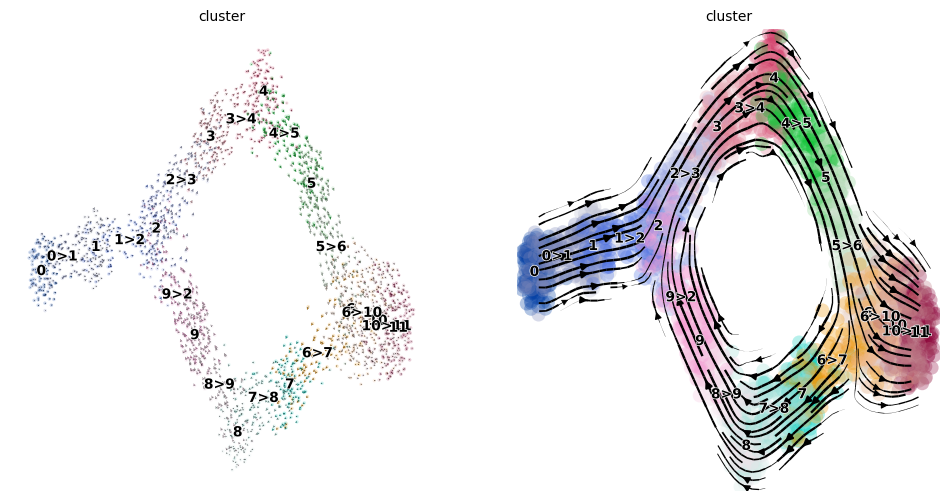

In [31]:
# Compute neighbors, UMAP, velocity embedding
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata, mode_neighbors="connectivities")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
scv.pl.velocity_embedding(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[0], show=False
)
scv.pl.velocity_embedding_stream(
    adata, color="cluster", legend_loc="on data", dpi=300, ax=axs[1], show=False
)

computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


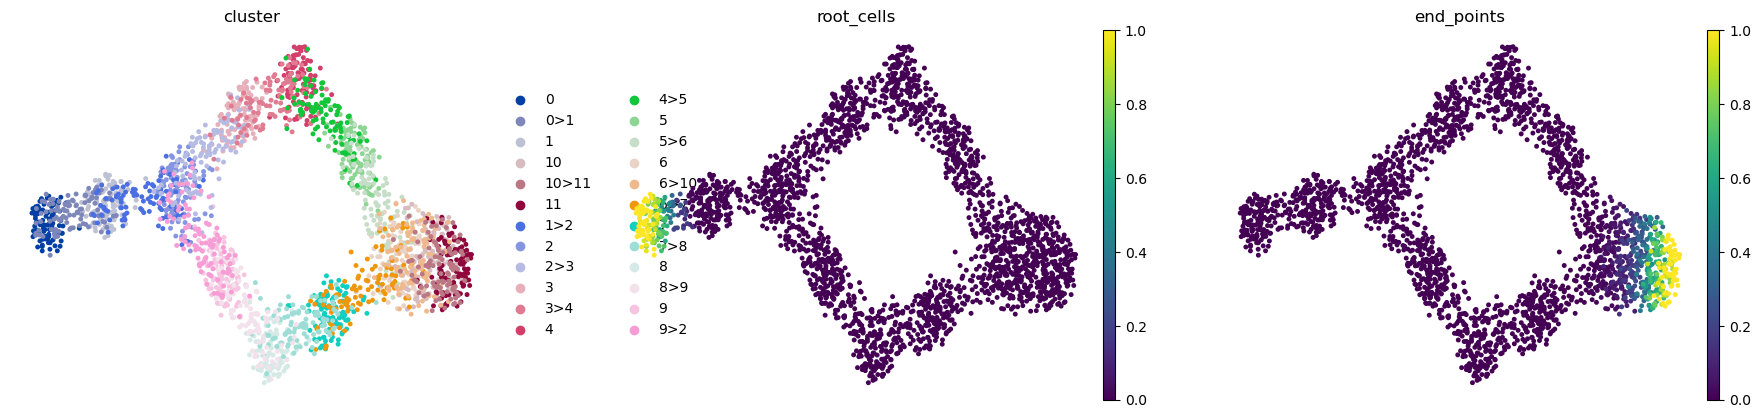

In [32]:
# Compute terminal states and transition matrix
scv.tl.terminal_states(adata)
adata.obsp["T_forward"] = scv.utils.get_transition_matrix(adata, self_transitions=False)
sc.pl.umap(adata, color=["cluster", "root_cells", "end_points"], frameon=False)

In [33]:
# Run Cy2path analyis
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    num_chains=1000,
    num_lineages="auto",
    max_lineages=6,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 51 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Finding optimal number of lineages between 2 and 6:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:root:Optimal number of lineages is 2 with silhouette score 0.255


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

<Axes: >

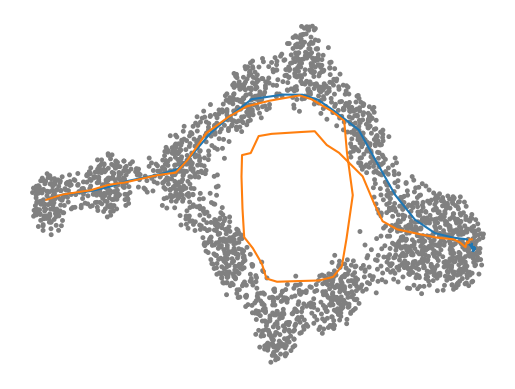

In [34]:
c2p.plot_cytopath_lineages(adata)

In [35]:
adata.uns["cytopath"]["silhouette_scores"] = {
    str(key): val for key, val in adata.uns["cytopath"]["silhouette_scores"].items()
}
adata.write_h5ad(os.path.join(OUT_DIR, "adata_cycle.h5ad"))